In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
df = pd.read_csv("../data/adult.csv")

In [26]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


Явных пропусков не выявлено

In [5]:
df.duplicated().sum()

np.int64(52)

In [6]:
df = df.drop_duplicates()

Удалили дубликаты


In [7]:
df['income'].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

Наблюдается дисбаланс

In [8]:
numeric = df.select_dtypes(include='number').columns.tolist()

In [9]:
numeric

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [10]:
category = df.select_dtypes(include='object').columns.tolist()

/var/folders/jt/pfrf2kqn59d1ph0418pyq4mr0000gn/T/ipykernel_53897/2110772613.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category = df.select_dtypes(include='object').columns.tolist()


In [11]:
category

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'income']

Разделили на категориальные и количественные признаки

In [12]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
def plot_boxplots(dataframe, num_columns):
    num_plots = len(num_columns)
    num_cols = min(2, num_plots) 
    num_rows = (num_plots + 1) // num_cols  
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6*num_rows))  

    for i, column in enumerate(num_columns):
        row = i // num_cols  
        col = i % num_cols  

        ax = axes[row, col] if num_rows > 1 else axes[col]
        dataframe.boxplot(column=column, ax=ax)  
        ax.set_title(f"Боксплот для столбца {column}")  
        ax.set_xlabel("Столбец") 
        ax.set_ylabel("Значение")  

    plt.tight_layout()  
    plt.show()

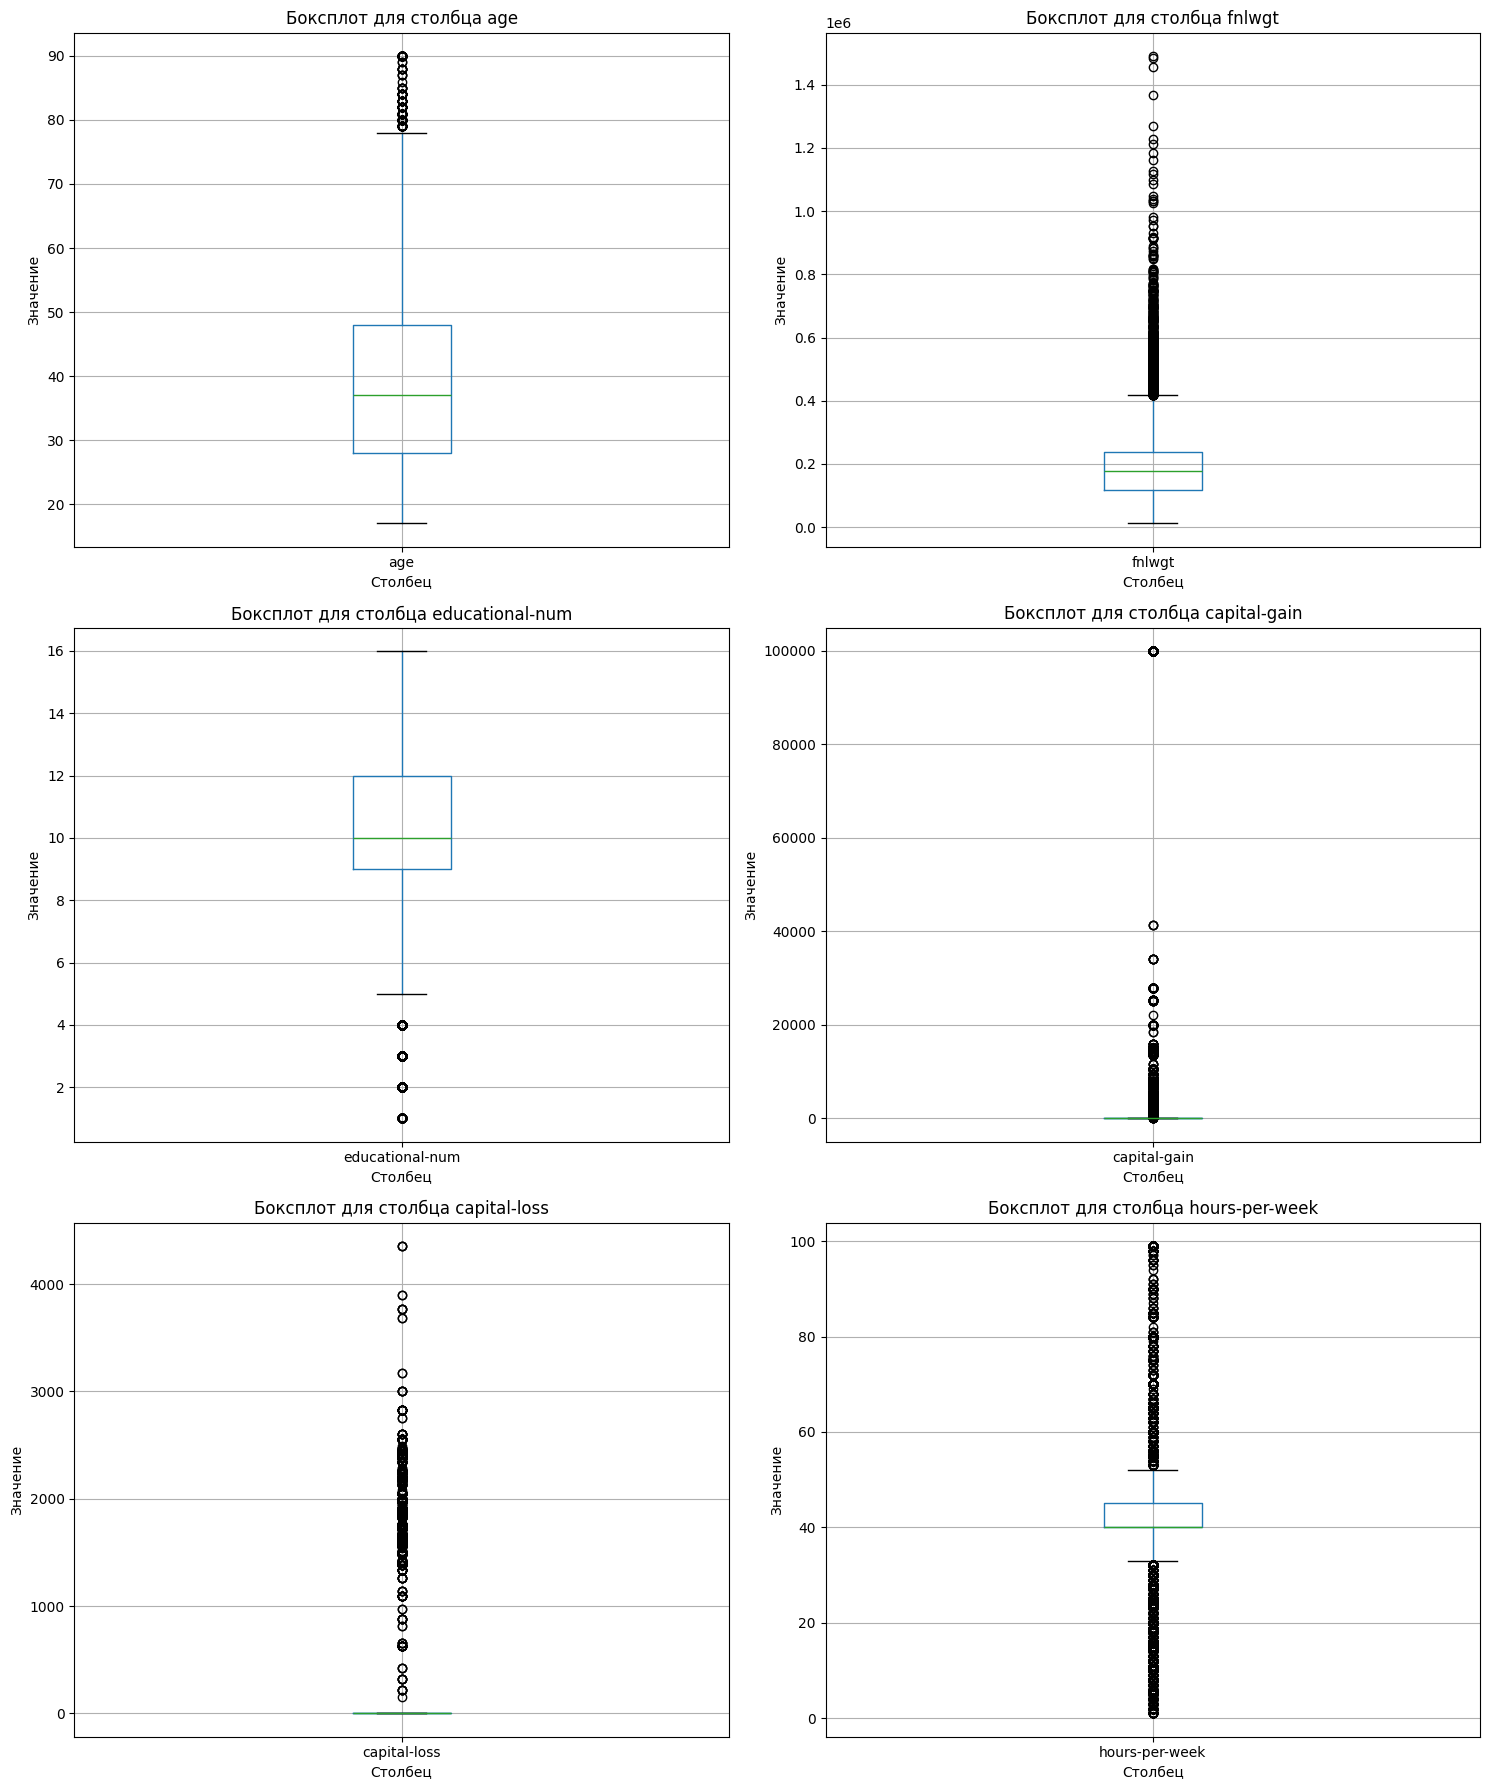

In [14]:
plot_boxplots(df, numeric)

В столбцах capital-gain и сapital-loss есть явные выбросы, как минимум 75% равны нулю

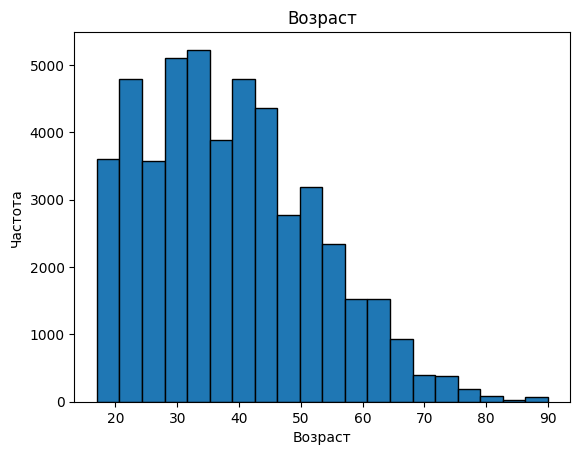

In [15]:
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Возраст')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

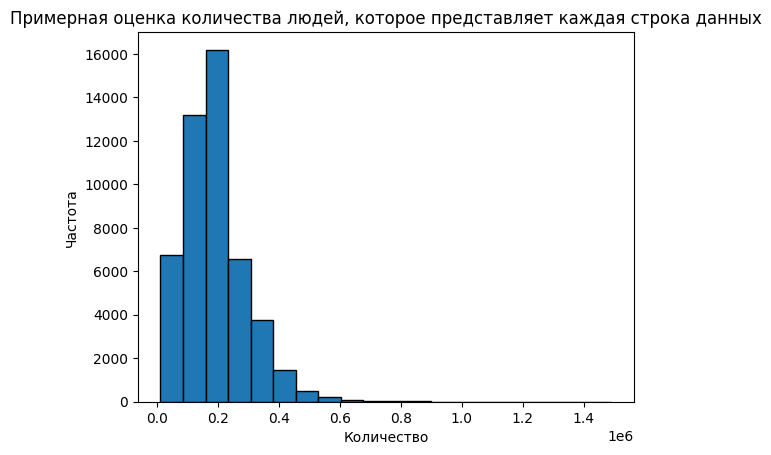

In [16]:
plt.hist(df['fnlwgt'], bins=20, edgecolor='black')
plt.title('Примерная оценка количества людей, которое представляет каждая строка данных')
plt.xlabel('Количество')
plt.ylabel('Частота')
plt.show()

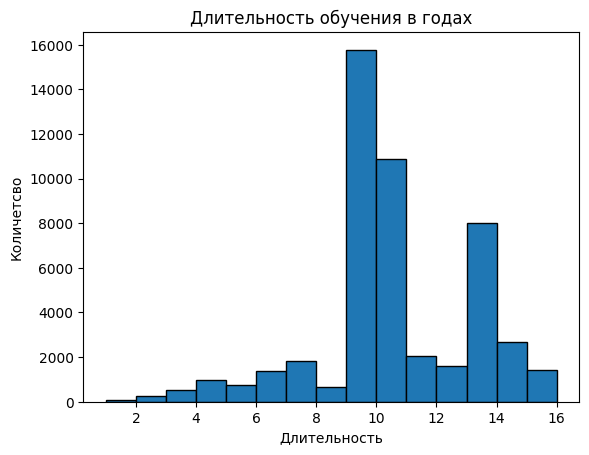

In [17]:
plt.hist(df['educational-num'], bins=15, edgecolor='black')
plt.title('Длительность обучения в годах')
plt.xlabel('Длительность')
plt.ylabel('Количетсво')
plt.show()

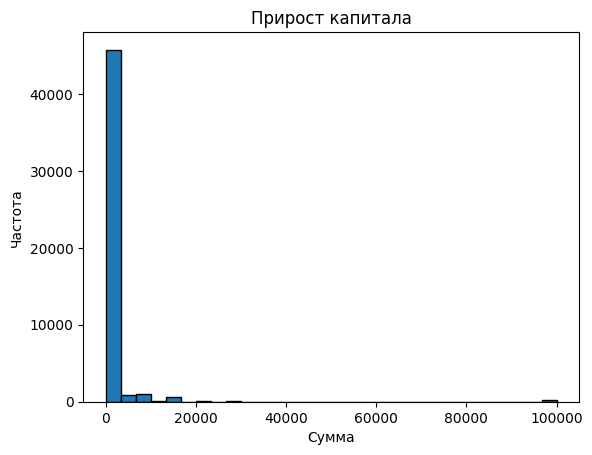

In [18]:
plt.hist(df['capital-gain'], bins=30, edgecolor='black')
plt.title('Прирост капитала')
plt.xlabel('Сумма')
plt.ylabel('Частота')
plt.show()

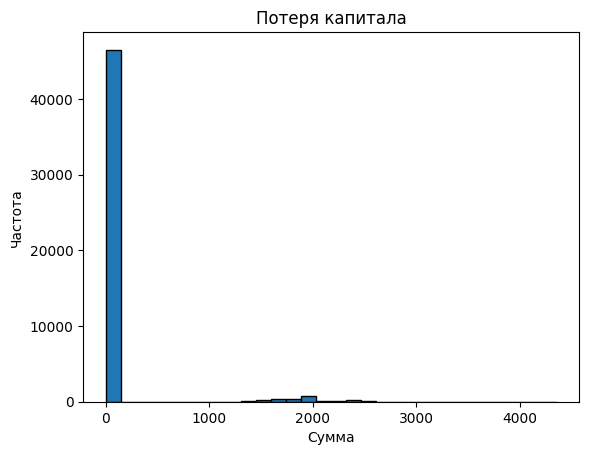

In [19]:
plt.hist(df['capital-loss'], bins=30, edgecolor='black')
plt.title('Потеря капитала')
plt.xlabel('Сумма')
plt.ylabel('Частота')
plt.show()

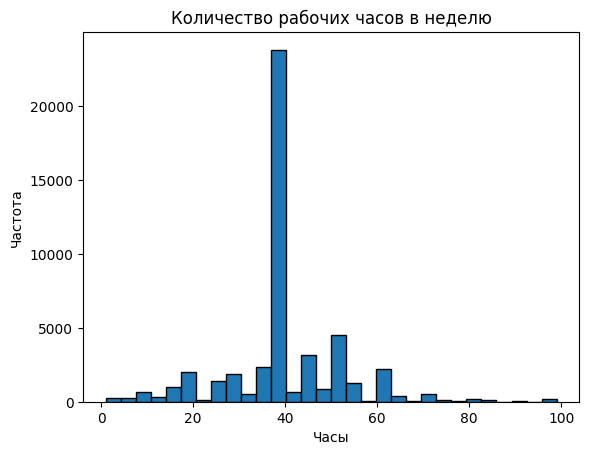

In [20]:
plt.hist(df['hours-per-week'], bins=30, edgecolor='black')
plt.title('Количество рабочих часов в неделю')
plt.xlabel('Часы')
plt.ylabel('Частота')
plt.show()

In [21]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


В столбцах capital-gain и сapital-loss есть явные выбросы, как минимум 75% равны нулю. Минимальный возраст 17 лет, максимальный 90. Большинство людей от 28 до 48.

Большинство людей учились около 10 лет.

В приросте и потере капитала наблюдаются явные выбросы, с которыми будет проведена работа.

Абсолютное большинство работает 40 часов в неделю

In [22]:
def unique_columns(columns, data):
    for column in columns:
        unique_values = set(data[column])
        print(f'уникальные значения в {column}: {unique_values}')


In [23]:
unique_columns(category, df)

уникальные значения в workclass: {'Never-worked', 'Local-gov', 'Federal-gov', '?', 'Private', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Self-emp-not-inc'}
уникальные значения в education: {'Prof-school', 'Bachelors', '1st-4th', 'Preschool', 'Assoc-voc', 'Masters', 'Some-college', '10th', 'HS-grad', '9th', '12th', '11th', '7th-8th', 'Doctorate', '5th-6th', 'Assoc-acdm'}
уникальные значения в marital-status: {'Separated', 'Widowed', 'Married-AF-spouse', 'Never-married', 'Married-spouse-absent', 'Divorced', 'Married-civ-spouse'}
уникальные значения в occupation: {'Protective-serv', 'Priv-house-serv', 'Other-service', 'Craft-repair', 'Tech-support', 'Sales', 'Adm-clerical', 'Farming-fishing', '?', 'Machine-op-inspct', 'Armed-Forces', 'Prof-specialty', 'Exec-managerial', 'Handlers-cleaners', 'Transport-moving'}
уникальные значения в relationship: {'Other-relative', 'Husband', 'Own-child', 'Wife', 'Unmarried', 'Not-in-family'}
уникальные значения в race: {'Other', 'Black', 'White', 'Asian

In [24]:
def create_pie_charts(data, columns, color='default'):
    for column in columns:
        counts = data[column].value_counts()

        df = pd.DataFrame({column: counts.index, 'count': counts.values})

        fig = px.pie(df, values='count', names=column, title=f'Круговая диаграмма для {column}')
        fig.show()

In [25]:
create_pie_charts(df, category)

На диаграмме отображается пропуск в workclass. Большинство людей работает в частном секторе.

Большинство людей получило среднее образование. 22.3% закончили колледж, 16.4% закончили бакалавариат.

60.9% не были женаты и 25.1% разведены.

По роду деятельности нет абсолютного большинства. Люди работают в ремонте, руководителями, офисными сотрудниками. 5.25% пропуск

В столбце relationship непонятно в каком значении описаны данные

Большинство людей относятся к белым 85.5%, к афро-американцам 9.6% и к представителям азии 3.11%

66.8% мужчины 33.2% женщины

В странах много значений, но абсолютное большинство США

У большинства доход меньше 50К (76.1%)